# Implemantation with Pytorch

## Essential setup

First, install dependencies.

In [1]:
!pip install torch
!pip install -q torchinfo
!pip install torchvision

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.3.1 -> 23.3.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.3.1 -> 23.3.2
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.3.1 -> 23.3.2
[notice] To update, run: pip install --upgrade pip


Import everything will need.

In [2]:
import torch
from torch import nn
from torchinfo import summary
import torchvision
from torch.optim import Adam 

## Load CSV

#### **For Local Usage**

In [3]:
# !pip install kaggle

In [4]:
# from kaggle.api.kaggle_api_extended import KaggleApi

# api = KaggleApi()
# api.authenticate()

# api.competition_download_files('challenges-in-representation-learning-facial-expression-recognition-challenge')

In [5]:
# !unzip -o challenges-in-representation-learning-facial-expression-recognition-challenge.zip -d dataset
# !tar -zxvf dataset/fer2013.tar.gz
# !mv fer2013/*.csv .
# !rm -r fer2013 dataset

#### Load

In [6]:
import pandas as pd

data = pd.read_csv("fer2013.csv")

#### **For Collab Usage**

In [7]:
# import pandas as pd
# url='https://drive.google.com/file/d/1mvtaXKK-QJLJr_jJWuaE7GRuUwUbzR2l/view?usp=sharing'
# path = 'https://drive.google.com/uc?export=download&confirm=1&id='+url.split('/')[-2]
# data = pd.read_csv(path)

## Define Transformations

The reason that the size of images has changed from 48x48 to 224x224, is because the use of a standardized input size is a common practice in computer vision tasks, especially when using pre-trained models on large datasets like ImageNet. This standardization facilitates interoperability and comparisons between different models.

In [8]:
from torchvision.transforms import Resize, ToTensor, Compose

transform = Compose([
    Resize((224, 224)),
    ToTensor()
])

## Create Dataset & DataLoader

In [9]:
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import numpy as np

class Fer2013Dataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        pixels = self.data.iloc[idx, 1].split(" ")
        pixels = [int(pixel) for pixel in pixels]
        pixels = np.array(pixels, dtype=np.uint8).reshape((48,48))


        emotion = self.data.iloc[idx, 0]

        image = Image.fromarray(pixels)
        
        if self.transform:
            image = self.transform(image)

        return image, emotion

BATCH_SIZE = 32

train_data = data[data['Usage'] == 'Training']
private_test_data = data[data['Usage'] == 'PrivateTest']
public_test_data = data[data['Usage'] == 'PublicTest']

train_dataset = Fer2013Dataset(train_data, transform=transform)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)

private_test_dataset = Fer2013Dataset(private_test_data, transform=transform)
private_test_dataloader = DataLoader(private_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, drop_last=True)

public_test_dataset = Fer2013Dataset(public_test_data, transform=transform)
public_test_dataloader = DataLoader(public_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, drop_last=True)

## Visualize Images

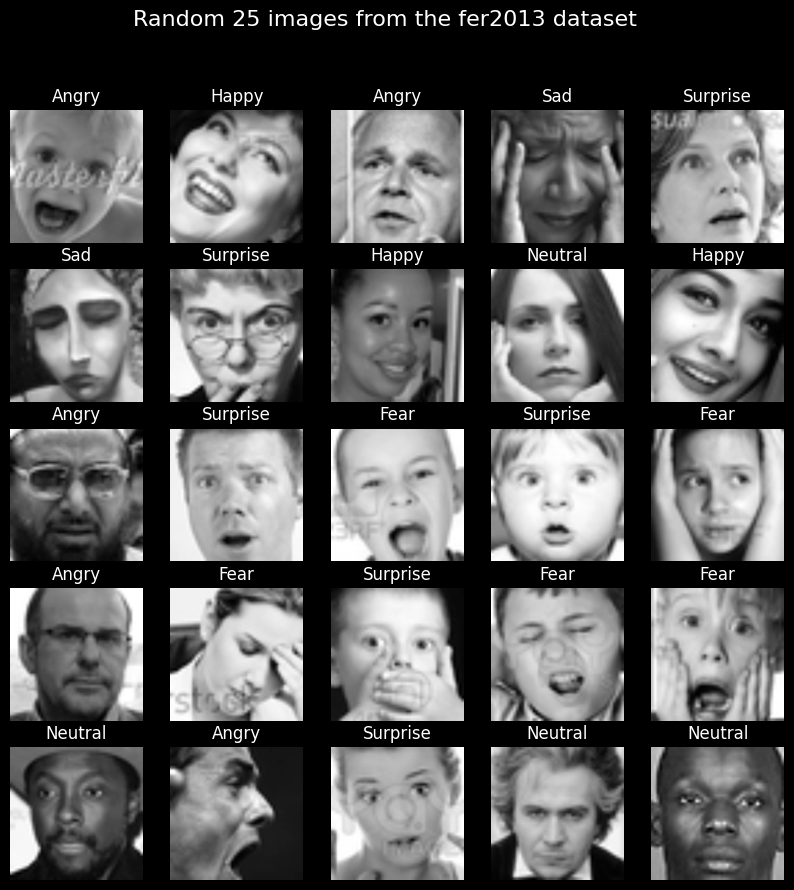

In [10]:
import matplotlib.pyplot as plt
import random

num_rows = 5
num_cols = num_rows

# Create a figure with subplots
fig, axs = plt.subplots(num_rows, num_cols, figsize=(10, 10))

# Define emotion labels for annotation
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Iterate over the subplots and display random images from the fer2013 dataset
for i in range(num_rows):
    for j in range(num_cols):
        # Choose a random index from the fer2013 dataset
        index = random.randrange(len(train_dataset))

        # Display the image in the subplot
        image, emotion = train_dataset[index]
        axs[i, j].imshow(image.squeeze().numpy(), cmap='gray')

        # Set the title of the subplot as the corresponding emotion label
        axs[i, j].set_title(emotion_labels[int(emotion)], color="white")

        # Disable the axis for better visualization
        axs[i, j].axis(False)

# Set the super title of the figure
fig.suptitle(f"Random {num_rows * num_cols} images from the fer2013 dataset", fontsize=16, color="white")

# Set the background color of the figure as black
fig.set_facecolor(color='black')

# Display the plot
plt.show()

## Create Patch Embedding layer

As we learned from the survey for ViT theory, They process we will do is (in brackets is considered our case):
- Convert the image into patches of 16x16 size.  
Image width and image height must be divisible by patch size.
- Embed each patch into (16\*16\*1)= 256 dimensions. So each patch becoms a [1x256] vector.  
By the mathematical occusion to find the number of patches N=H*W/P**2 occurs that N=196, which root of this is 14.  
This results in an image that is of the shape [14x14x256].  
*<u>Note:</u>* A smaller patch size allow for more detailed spatial information but may increase computational costs.
- Flatten the image along a single vector. THis will give a [196x256] Matrix, which is our Image Embedding Sequence.
- Prepend the Class Token Embeddings to the above output.
- Add the Position Embeddings to the Class Token and Image Embeddings.  
**All above bullets plus the image size constitute the hyperparameters.**

In [11]:
PATCH_SIZE = 16
IMAGE_WIDTH = 224
IMAGE_HEIGHT = IMAGE_WIDTH
IMAGE_CHANNELS = 1
EMBEDDING_DIMS = IMAGE_CHANNELS * PATCH_SIZE**2
NUM_OF_PATCHES = int((IMAGE_WIDTH * IMAGE_HEIGHT) / PATCH_SIZE**2)

assert IMAGE_WIDTH % PATCH_SIZE == 0 and IMAGE_HEIGHT % PATCH_SIZE ==0 , print("Image Width is not divisible by patch size")

### Converting the image into patches of 16x16 and creating an embedding vector for each patch size 256.

2D Convolution Layer creation with hyperparameters. 

In [12]:
conv_layer = nn.Conv2d(in_channels = IMAGE_CHANNELS, out_channels = EMBEDDING_DIMS, kernel_size = PATCH_SIZE, stride = PATCH_SIZE)

Get a random batch of images from dataloader and show the first of them with its label.

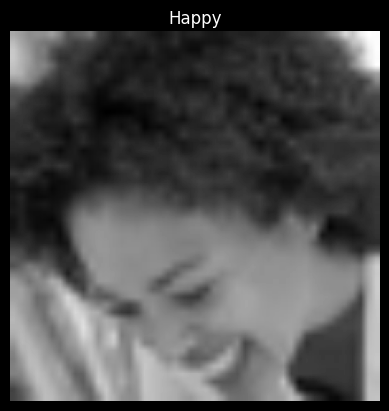

In [13]:
random_images, random_labels = next(iter(train_dataloader))
random_image = random_images[0]

fig = plt.figure(1)

plt.imshow(random_image.squeeze().numpy(), cmap='gray')

# Disable the axis for better visualization
plt.axis(False)

plt.title(emotion_labels[int(random_labels[0])], color="white")

fig.set_facecolor(color="black")

plt.show()

Pass the 1st image through convolution layer.  
**Unsqueeze(0)** is used to add a batch dimension to the image, making it compatible with the expected input shape of the convolutional layer.  
**permute:** Change the order of dimensions in image_through_conv to make tensor compatible with downstream operations.  
Create the flatten layer and pass the image_through_conv through flatten_layer.  
Embedding image has now the representation of random image after proccesing.  
This is what we achieve:
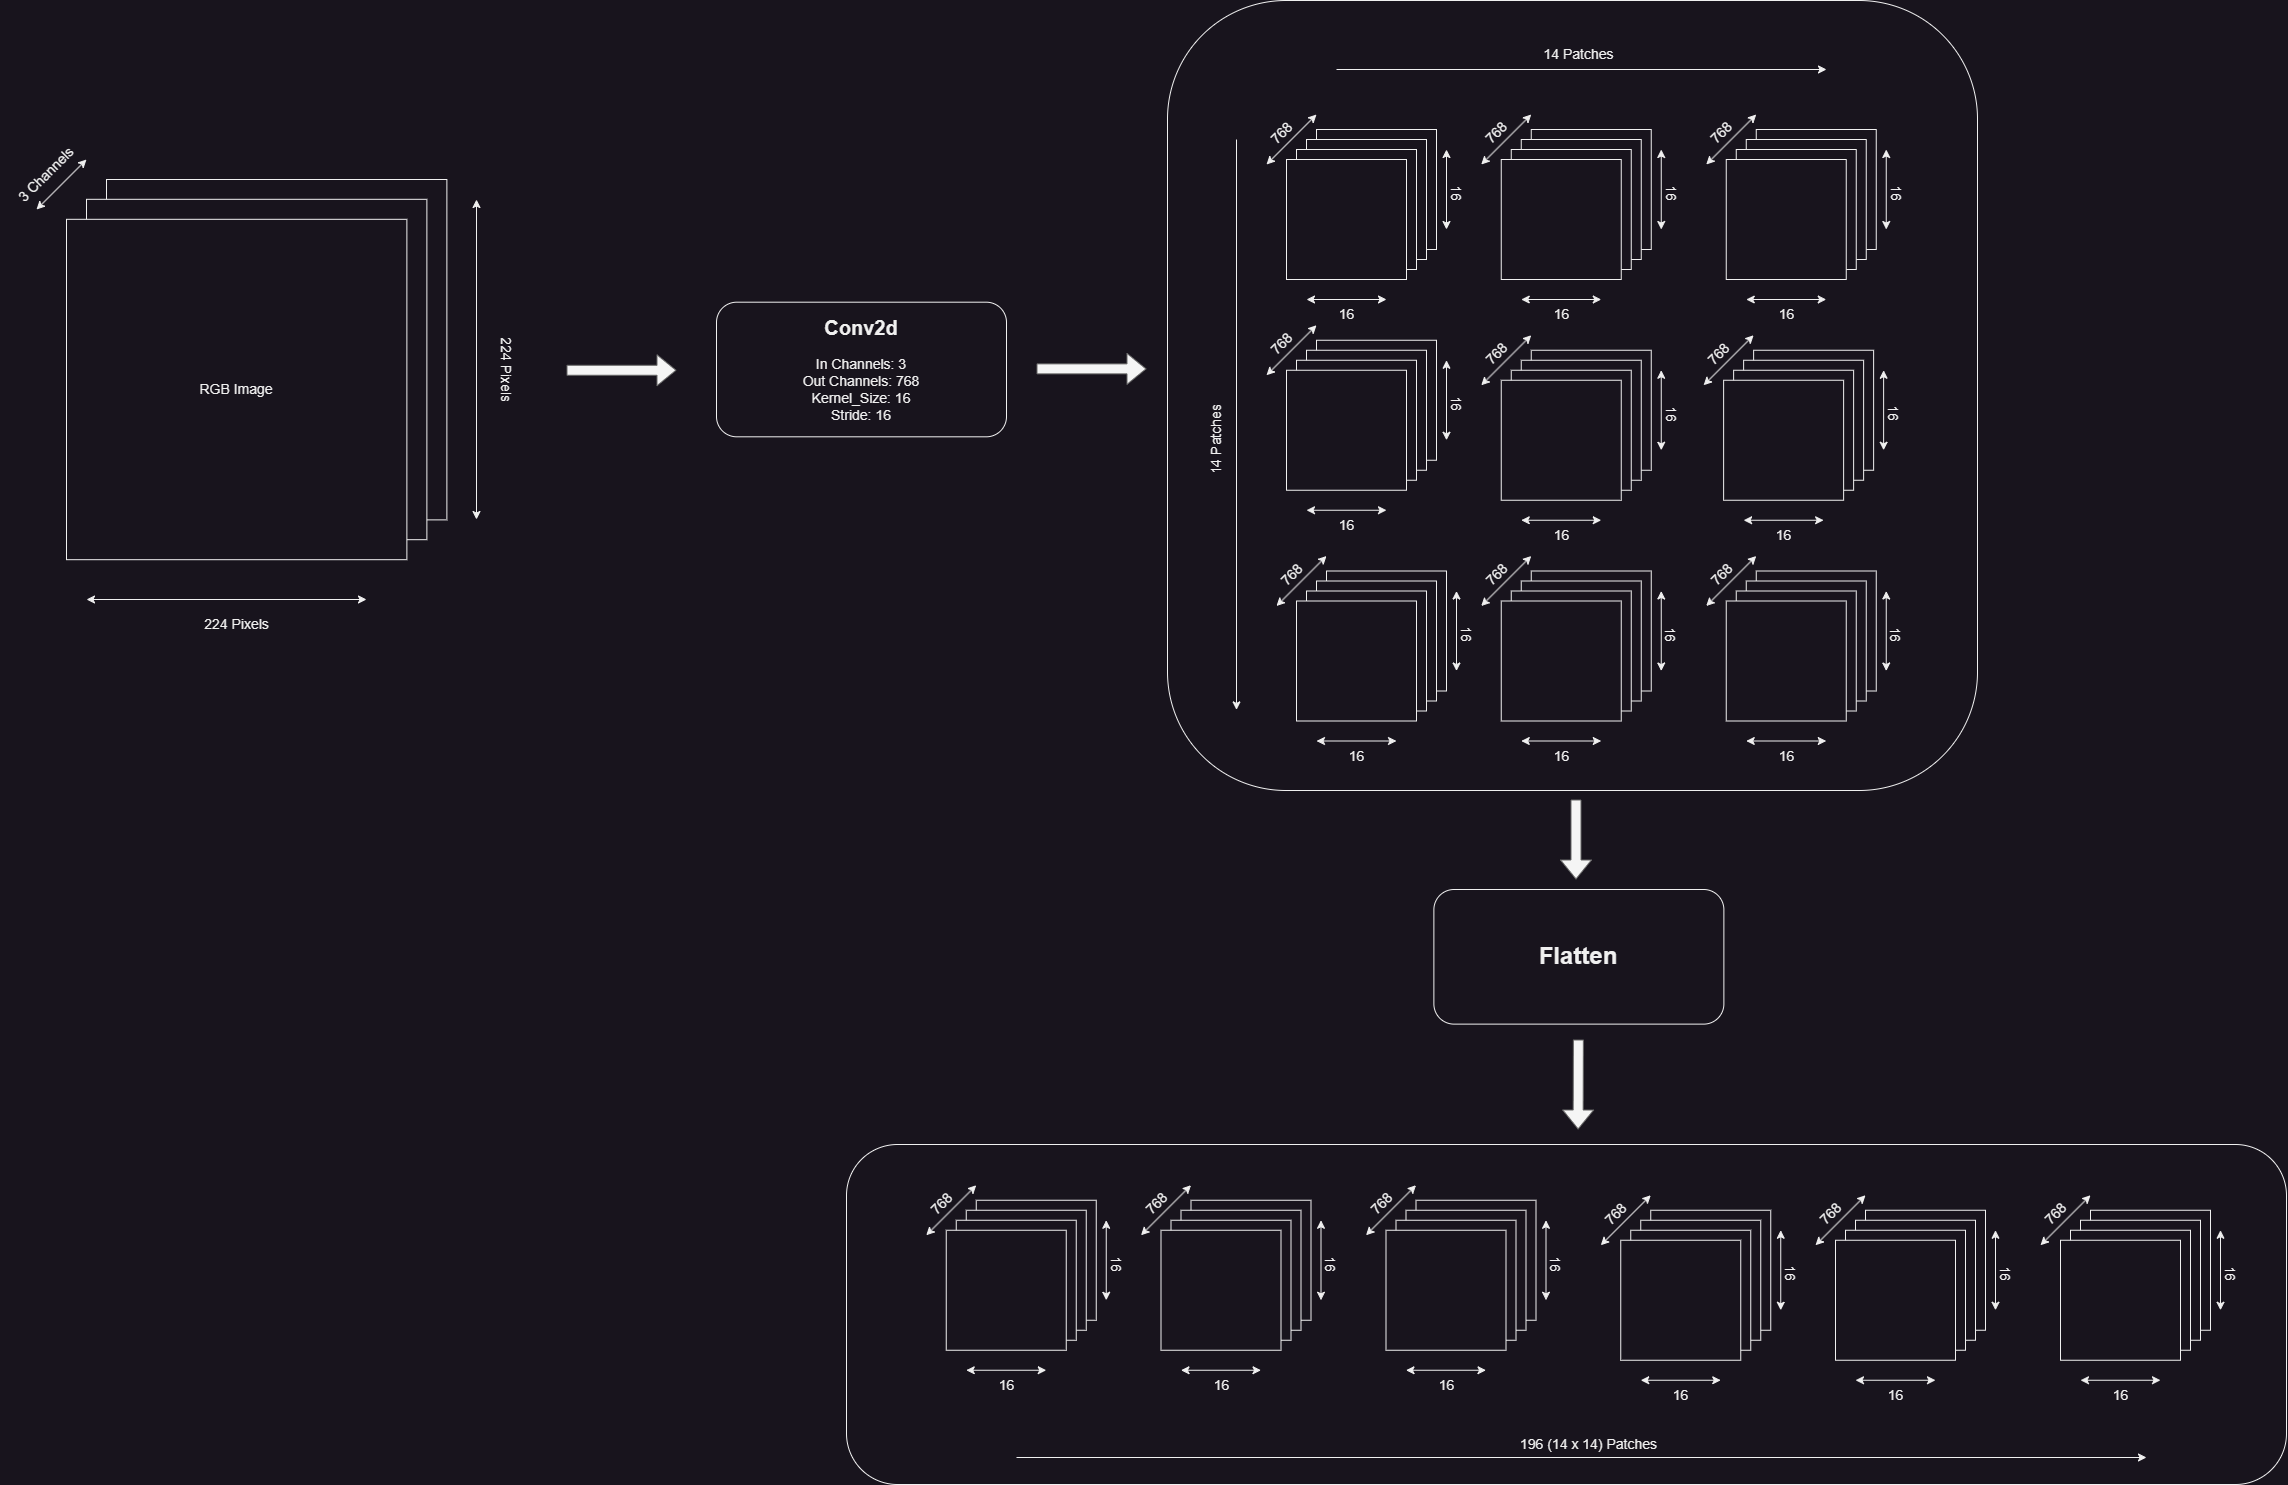

In [14]:
image_through_conv = conv_layer(random_image.unsqueeze(0))
print(f'Shape of embeddings through the conv layer -> {list(image_through_conv.shape)} <- [batch_size, num_of_patch_rows,num_patch_cols embedding_dims]')

image_through_conv = image_through_conv.permute((0, 2, 3, 1))

flatten_layer = nn.Flatten(start_dim=1, end_dim=2)

image_through_conv_and_flatten = flatten_layer(image_through_conv)


print(f'Shape of embeddings through the flatten layer -> {list(image_through_conv_and_flatten.shape)} <- [batch_size, num_of_patches, embedding_dims]')

# Assign the embedded image to a variable
embedded_image = image_through_conv_and_flatten

Shape of embeddings through the conv layer -> [1, 256, 14, 14] <- [batch_size, num_of_patch_rows,num_patch_cols embedding_dims]
Shape of embeddings through the flatten layer -> [1, 196, 256] <- [batch_size, num_of_patches, embedding_dims]


### Prepending the Class Token Embedding and Adding the Position Embeddings

**class_token_embeddings** is a learnable parameter, which represents an embedding for a special token often called the "class token" or "CLS token." This token is typically used in transformer architectures to represent the entire sequence or image.  
**embedded_image_with_class_token_embeddings** connects the class_token_embeddings with the previously embedded_image.  
**position_embeddings** are used to encode the positional information of tokens or patches in the sequence.

In [15]:
class_token_embeddings = nn.Parameter(torch.rand((1, 1,EMBEDDING_DIMS), requires_grad  = True))
print(f'Shape of class_token_embeddings --> {list(class_token_embeddings.shape)} <-- [batch_size, 1, emdedding_dims]') # single example in the batch, one token, and the specified embedding dimensions

embedded_image_with_class_token_embeddings = torch.cat((class_token_embeddings, embedded_image), dim = 1)
print(f'\nShape of image embeddings with class_token_embeddings --> {list(embedded_image_with_class_token_embeddings.shape)} <-- [batch_size, num_of_patches+1, embeddiing_dims]')

position_embeddings = nn.Parameter(torch.rand((1, NUM_OF_PATCHES+1, EMBEDDING_DIMS ), requires_grad = True ))
print(f'\nShape of position_embeddings --> {list(position_embeddings.shape)} <-- [batch_size, num_patches+1, embeddings_dims]')

final_embeddings = embedded_image_with_class_token_embeddings + position_embeddings
print(f'\nShape of final_embeddings --> {list(final_embeddings.shape)} <-- [batch_size, num_patches+1, embeddings_dims]')

Shape of class_token_embeddings --> [1, 1, 256] <-- [batch_size, 1, emdedding_dims]

Shape of image embeddings with class_token_embeddings --> [1, 197, 256] <-- [batch_size, num_of_patches+1, embeddiing_dims]

Shape of position_embeddings --> [1, 197, 256] <-- [batch_size, num_patches+1, embeddings_dims]

Shape of final_embeddings --> [1, 197, 256] <-- [batch_size, num_patches+1, embeddings_dims]


#### Put the PatchEmbedddingLayer Together

From the PyTorch nn.Module we will create custom layer which for input take an image and for output throws the patch embeddings which consists of the Image Embeddings, Class Token Embeddings and the Position Embeddings.  
We using all the definitions we gave before.  


In [16]:
class PatchEmbeddingLayer(nn.Module):
    def __init__(self, in_channels, patch_size, embedding_dim,):
        super().__init__()
        self.patch_size = patch_size
        self.embedding_dim = embedding_dim
        self.in_channels = in_channels
        self.conv_layer = nn.Conv2d(in_channels=in_channels, out_channels=embedding_dim, kernel_size=patch_size, stride=patch_size)
        self.flatten_layer = nn.Flatten(start_dim=1, end_dim=2)
        self.class_token_embeddings = nn.Parameter(torch.rand((BATCH_SIZE, 1, EMBEDDING_DIMS), requires_grad=True))
        self.position_embeddings = nn.Parameter(torch.rand((1, NUM_OF_PATCHES + 1, EMBEDDING_DIMS), requires_grad=True))

    def forward(self, x):
        output = torch.cat((self.class_token_embeddings, self.flatten_layer(self.conv_layer(x).permute((0, 2, 3, 1)))), dim=1) + self.position_embeddings
        return output

Let's try some randoms images.

In [17]:
patch_embedding_layer = PatchEmbeddingLayer(in_channels=IMAGE_CHANNELS, patch_size=PATCH_SIZE, embedding_dim=IMAGE_CHANNELS * PATCH_SIZE ** 2)

patch_embeddings = patch_embedding_layer(random_images)
patch_embeddings.shape

torch.Size([32, 197, 256])

In [18]:
summary(model=patch_embedding_layer,
        input_size=(BATCH_SIZE, 1, 224, 224), # (batch_size, input_channels, img_width, img_height)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
PatchEmbeddingLayer (PatchEmbeddingLayer)     [32, 1, 224, 224]    [32, 197, 256]       58,624               True
├─Conv2d (conv_layer)                         [32, 1, 224, 224]    [32, 256, 14, 14]    65,792               True
├─Flatten (flatten_layer)                     [32, 14, 14, 256]    [32, 196, 256]       --                   --
Total params: 124,416
Trainable params: 124,416
Non-trainable params: 0
Total mult-adds (M): 412.65
Input size (MB): 6.42
Forward/backward pass size (MB): 12.85
Params size (MB): 0.26
Estimated Total Size (MB): 19.53

## Multi-Head Self Attention (MSA)

We will create an MSA block as a class so we can call it easily.  
The figures compiled below are based on the paper "AN I MAGE IS WORTH 16X16 WORDS: TRANSFORMERS FOR I MAGE RECOGNITION AT SCALE", but in our case we have grayscale images so they are not so many embedding dimensions.

In [19]:
class MultiHeadSelfAttentionBlock(nn.Module):
  def __init__(self,
               embedding_dims = 756, # Hidden Size D in the ViT Paper Table 1
               num_heads = 12,  # Heads in the ViT Paper Table 1
               attn_dropout = 0.0 # Default to Zero as there is no dropout for the the MSA Block as per the ViT Paper
               ):
    super().__init__()

    self.embedding_dims = embedding_dims
    self.num_head = num_heads
    self.attn_dropout = attn_dropout

    self.layernorm = nn.LayerNorm(normalized_shape = embedding_dims)

    self.multiheadattention =  nn.MultiheadAttention(num_heads = num_heads,
                                                     embed_dim = embedding_dims,
                                                     dropout = attn_dropout,
                                                     batch_first = True,
                                                    )

  def forward(self, x):
    x = self.layernorm(x)
    output,_ = self.multiheadattention(query=x, key=x, value=x,need_weights=False)
    return output

Because of embed_dim must be divisible by num_heads we change this hyperparameter with number 8.

In [20]:
multihead_self_attention_block = MultiHeadSelfAttentionBlock(embedding_dims = EMBEDDING_DIMS, num_heads = 8)
print(f'Shape of the input Patch Embeddings => {list(patch_embeddings.shape)} <= [batch_size, num_patches+1, embedding_dims ]')
print(f'Shape of the output from MSA Block => {list(multihead_self_attention_block(patch_embeddings).shape)} <= [batch_size, num_patches+1, embedding_dims ]')

Shape of the input Patch Embeddings => [32, 197, 256] <= [batch_size, num_patches+1, embedding_dims ]
Shape of the output from MSA Block => [32, 197, 256] <= [batch_size, num_patches+1, embedding_dims ]


In [21]:
summary(model=multihead_self_attention_block,
        input_size=(1, 197, 256), # (batch_size, num_patches, embedding_dimension)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
MultiHeadSelfAttentionBlock (MultiHeadSelfAttentionBlock)    [1, 197, 256]        [1, 197, 256]        --                   True
├─LayerNorm (layernorm)                                      [1, 197, 256]        [1, 197, 256]        512                  True
├─MultiheadAttention (multiheadattention)                    --                   [1, 197, 256]        263,168              True
Total params: 263,680
Trainable params: 263,680
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.20
Forward/backward pass size (MB): 0.40
Params size (MB): 0.00
Estimated Total Size (MB): 0.61

## Machine Learning Perceptron (MLP)

Attention Dropout (attn_dropout):
- Dropout is used to prevent overfitting. The optimal dropout rate can vary.  
- Common values are in the range of 0.1 to 0.5.  

MLP Dropout (mlp_dropout):
- Similar to attention dropout, dropout in the MLP block helps prevent overfitting.  
- Experiment with values in the range of 0.1 to 0.5.  

MLP Hidden Size (mlp_size):
- This parameter determines the size of the hidden layer in the feedforward MLP block.  
- Increasing it may allow the model to learn more complex representations.

In [22]:
class MachineLearningPerceptronBlock(nn.Module):
  def __init__(self, embedding_dims, mlp_size, mlp_dropout):
    super().__init__()
    self.embedding_dims = embedding_dims
    self.mlp_size = mlp_size
    self.dropout = mlp_dropout

    self.layernorm = nn.LayerNorm(normalized_shape = embedding_dims)
    self.mlp = nn.Sequential(
        nn.Linear(in_features = embedding_dims, out_features = mlp_size),
        nn.GELU(),
        nn.Dropout(p = mlp_dropout),
        nn.Linear(in_features = mlp_size, out_features = embedding_dims),
        nn.Dropout(p = mlp_dropout)
    )

  def forward(self, x):
    return self.mlp(self.layernorm(x))

In [23]:
class TransformerBlock(nn.Module):
  def __init__(self, embedding_dims = 768,
               mlp_dropout=0.1,
               attn_dropout=0.0,
               mlp_size = 3072,
               num_heads = 12,
               ):
    super().__init__()

    self.msa_block = MultiHeadSelfAttentionBlock(embedding_dims = embedding_dims, num_heads = num_heads, attn_dropout = attn_dropout)

    self.mlp_block = MachineLearningPerceptronBlock(embedding_dims = embedding_dims, mlp_size = mlp_size, mlp_dropout = mlp_dropout)

  def forward(self,x):
    x = self.msa_block(x) + x
    x = self.mlp_block(x) + x

    return x

In [24]:
transformer_block = TransformerBlock(embedding_dims = EMBEDDING_DIMS,
                                     mlp_dropout = 0.1,
                                     attn_dropout=0.0,
                                     mlp_size = 512,
                                     num_heads = 8)

print(f'Shape of the input Patch Embeddings => {list(patch_embeddings.shape)} <= [batch_size, num_patches+1, embedding_dims ]')
print(f'Shape of the output from Transformer Block => {list(transformer_block(patch_embeddings).shape)} <= [batch_size, num_patches+1, embedding_dims ]')

Shape of the input Patch Embeddings => [32, 197, 256] <= [batch_size, num_patches+1, embedding_dims ]
Shape of the output from Transformer Block => [32, 197, 256] <= [batch_size, num_patches+1, embedding_dims ]


In [25]:
summary(model=transformer_block,
        input_size=(1, 197, 256), # (batch_size, num_patches, embedding_dimension)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerBlock (TransformerBlock)                [1, 197, 256]        [1, 197, 256]        --                   True
├─MultiHeadSelfAttentionBlock (msa_block)          [1, 197, 256]        [1, 197, 256]        --                   True
│    └─LayerNorm (layernorm)                       [1, 197, 256]        [1, 197, 256]        512                  True
│    └─MultiheadAttention (multiheadattention)     --                   [1, 197, 256]        263,168              True
├─MachineLearningPerceptronBlock (mlp_block)       [1, 197, 256]        [1, 197, 256]        --                   True
│    └─LayerNorm (layernorm)                       [1, 197, 256]        [1, 197, 256]        512                  True
│    └─Sequential (mlp)                            [1, 197, 256]        [1, 197, 256]        --                   True
│    │    └─Linear (0)                     

## Putting All Together to Create the Transformer

In [26]:
class TransformerBlock(nn.Module):
  def __init__(self, embedding_dims = 768,
               mlp_dropout=0.1,
               attn_dropout=0.0,
               mlp_size = 3072,
               num_heads = 12,
               ):
    super().__init__()

    self.msa_block = MultiHeadSelfAttentionBlock(embedding_dims = embedding_dims,
                                                 num_heads = num_heads,
                                                 attn_dropout = attn_dropout)

    self.mlp_block = MachineLearningPerceptronBlock(embedding_dims = embedding_dims,
                                                    mlp_size = mlp_size,
                                                    mlp_dropout = mlp_dropout,
                                                    )

  def forward(self,x):
    x = self.msa_block(x) + x
    x = self.mlp_block(x) + x

    return x

In [27]:
transformer_block = TransformerBlock(embedding_dims = EMBEDDING_DIMS,
                                     mlp_dropout = 0.1,
                                     attn_dropout=0.0,
                                     mlp_size = 512,
                                     num_heads = 8)

print(f'Shape of the input Patch Embeddings => {list(patch_embeddings.shape)} <= [batch_size, num_patches+1, embedding_dims ]')
print(f'Shape of the output from Transformer Block => {list(transformer_block(patch_embeddings).shape)} <= [batch_size, num_patches+1, embedding_dims ]')

Shape of the input Patch Embeddings => [32, 197, 256] <= [batch_size, num_patches+1, embedding_dims ]
Shape of the output from Transformer Block => [32, 197, 256] <= [batch_size, num_patches+1, embedding_dims ]


In [28]:
summary(model=transformer_block,
        input_size=(1, 197, 256), # (batch_size, num_patches, embedding_dimension)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerBlock (TransformerBlock)                [1, 197, 256]        [1, 197, 256]        --                   True
├─MultiHeadSelfAttentionBlock (msa_block)          [1, 197, 256]        [1, 197, 256]        --                   True
│    └─LayerNorm (layernorm)                       [1, 197, 256]        [1, 197, 256]        512                  True
│    └─MultiheadAttention (multiheadattention)     --                   [1, 197, 256]        263,168              True
├─MachineLearningPerceptronBlock (mlp_block)       [1, 197, 256]        [1, 197, 256]        --                   True
│    └─LayerNorm (layernorm)                       [1, 197, 256]        [1, 197, 256]        512                  True
│    └─Sequential (mlp)                            [1, 197, 256]        [1, 197, 256]        --                   True
│    │    └─Linear (0)                     

In [41]:
class ViT(nn.Module):
  def __init__(self, img_size = 224,
               in_channels = 1,
               patch_size = 16,
               embedding_dims = 256,
               num_transformer_layers = 4, # from table 1 above
               mlp_dropout = 0.1,
               attn_dropout = 0.0,
               mlp_size = 512,
               num_heads = 8,
               num_classes = 7):
    super().__init__()

    self.patch_embedding_layer = PatchEmbeddingLayer(in_channels = in_channels,
                                                     patch_size=patch_size,
                                                     embedding_dim = embedding_dims)

    self.transformer_encoder = nn.Sequential(*[TransformerBlock(embedding_dims = embedding_dims,
                                              mlp_dropout = mlp_dropout,
                                              attn_dropout = attn_dropout,
                                              mlp_size = mlp_size,
                                              num_heads = num_heads) for _ in range(num_transformer_layers)])

    self.classifier = nn.Sequential(nn.LayerNorm(normalized_shape = embedding_dims),
                                    nn.Linear(in_features = embedding_dims,
                                              out_features = num_classes))

  def forward(self, x):
    return self.classifier(self.transformer_encoder(self.patch_embedding_layer(x))[:, 0])


In [42]:
summary(model=ViT(),
        input_size=(BATCH_SIZE, 1, 224, 224), # (batch_size, num_patches, embedding_dimension)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
ViT (ViT)                                                    [32, 1, 224, 224]    [32, 7]              --                   True
├─PatchEmbeddingLayer (patch_embedding_layer)                [32, 1, 224, 224]    [32, 197, 256]       58,624               True
│    └─Conv2d (conv_layer)                                   [32, 1, 224, 224]    [32, 256, 14, 14]    65,792               True
│    └─Flatten (flatten_layer)                               [32, 14, 14, 256]    [32, 196, 256]       --                   --
├─Sequential (transformer_encoder)                           [32, 197, 256]       [32, 197, 256]       --                   True
│    └─TransformerBlock (0)                                  [32, 197, 256]       [32, 197, 256]       --                   True
│    │    └─MultiHeadSelfAttentionBlock (msa_block)          [32, 197, 256]       [32, 197, 25

## Training

### Loss Function

In training loop, we would use this criterion to compute the loss and backpropagate the gradients.

In [43]:
criterion = nn.CrossEntropyLoss()

### Training Loop

In [44]:
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ViT().to(device)
learning_rate = 1e-3
number_epochs = 75
validation_interval = 5  # Perform validation every 5 epochs

optimizer = Adam(model.parameters(), lr=learning_rate)

# Assuming you have a combined validation dataloader including the public test set named 'public_test_dataloader'
total_val_batches = len(public_test_dataloader)

for epoch in range(number_epochs):
    model.train()
    total_loss = 0.0

    for batch_idx, (inputs, labels) in enumerate(tqdm(train_dataloader, desc=f'Epoch {epoch + 1}/{number_epochs}', unit='batch')):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_dataloader)
    print(f'Training Loss (Epoch {epoch + 1}/{number_epochs}): {average_loss:.4f}')

    # Validation
    if (epoch + 1) % validation_interval == 0:
        model.eval()
        total_val_loss = 0.0

        with torch.no_grad():
            for val_batch_idx, (val_inputs, val_labels) in enumerate(tqdm(public_test_dataloader, desc=f'Validation (Epoch {epoch + 1}/{number_epochs})', unit='batch')):
                val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)

                val_outputs = model(val_inputs)
                val_loss = criterion(val_outputs, val_labels)
                total_val_loss += val_loss.item()

            average_val_loss = total_val_loss / total_val_batches
            print(f'Validation Loss (Epoch {epoch + 1}/{number_epochs}): {average_val_loss:.4f}')

# Save the trained model if needed
torch.save(model.state_dict(), 'vit_model.pth')

Epoch 1/75:   0%|          | 0/897 [00:00<?, ?batch/s]

Epoch 1/75: 100%|██████████| 897/897 [01:01<00:00, 14.68batch/s]


Training Loss (Epoch 1/75): 1.8084


Epoch 2/75: 100%|██████████| 897/897 [01:00<00:00, 14.94batch/s]


Training Loss (Epoch 2/75): 1.7636


...

Training Loss (Epoch 74/75): 1.5039


Epoch 75/75: 100%|██████████| 897/897 [01:02<00:00, 14.43batch/s]


Training Loss (Epoch 75/75): 1.5023


Validation (Epoch 75/75): 100%|██████████| 112/112 [00:01<00:00, 62.31batch/s]

Validation Loss (Epoch 75/75): 1.6285


## Evaluation

Accuracy: 0.3605
Classification Report:
               precision    recall  f1-score   support

     Class 0       0.26      0.13      0.18       467
     Class 1       0.71      0.09      0.16        56
     Class 2       0.21      0.17      0.19       496
     Class 3       0.45      0.57      0.50       894
     Class 4       0.31      0.32      0.31       649
     Class 5       0.49      0.49      0.49       415
     Class 6       0.31      0.38      0.34       607

    accuracy                           0.36      3584
   macro avg       0.39      0.30      0.31      3584
weighted avg       0.35      0.36      0.35      3584



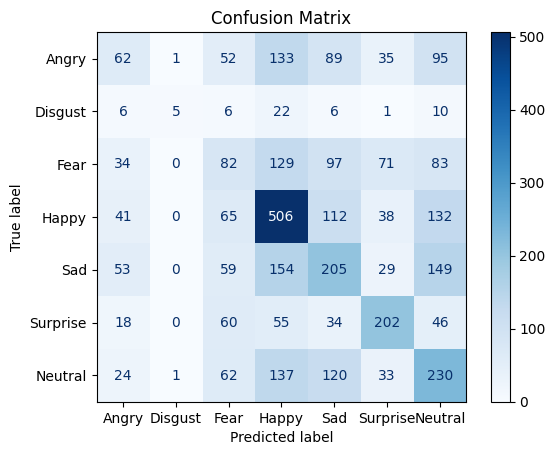

In [50]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
num_classes = 7
true_labels = []
predicted_labels = []

with torch.no_grad():
    for inputs, labels in public_test_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predictions = torch.max(outputs, 1)

        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predictions.cpu().numpy())

accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy:.4f}")

class_report = classification_report(true_labels, predicted_labels, target_names=[f'Class {i}' for i in range(num_classes)])
print("Classification Report:\n", class_report)

conf_matrix = confusion_matrix(true_labels, predicted_labels)
# print("Confusion Matrix:\n", conf_matrix)

disp = ConfusionMatrixDisplay(conf_matrix, display_labels = emotion_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()